# Unit 17: **Enzymatic and heterogenous catalysis. Michaelis-Menten equation and Langmuir and BET isotherms.**

# 1. Theory

# 2. Examples

## Problem 1

Given the following data for some enzymatic reaction, determine: a) the Michaelis constant, $K_M$; 2) thereaction rate constant for the product formation step ($k_2$); and 3) the maximal rate of reaction, $r_{max}$. The initial concentration of the enzyme is $[E]_0 = 3.8\times 10^{-5} M$

Data: 

units of $S_0$ are $M$;  units of $r_0$ are $M s^{-1}$

| $S_0$ |  $r_0$  |
| --- | --- |
| 0.20 | $4.57 \times 10^{-6}$ |
| 0.124 | $3.83 \times 10^{-6}$ |
| 0.091 | $3.31 \times 10^{-6}$ |
| 0.071 | $2.93 \times 10^{-6}$ |
| 0.060 | $2.74 \times 10^{-6}$ |


### Solution

K_M = 0.0803054226526894, M; r_max = 6.316721377771956e-06 M/s; k2 = 0.16622950994136726 1/s


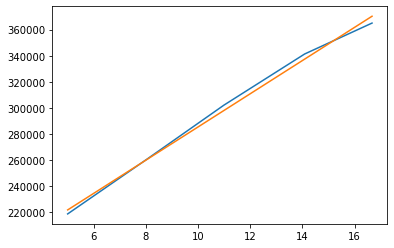

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def linfit(x, A, B):
    return  A +  B * x

#popt, pcov = curve_fit( guess1, inv_s, inv_r, bounds=([-np.inf, -np.inf],[np.inf, np.inf]))
#A, B = popt[0], popt[1]

# Initial data
s = np.array([0.2, 0.124, 0.091, 0.071, 0.060])
r = np.array([4.57, 3.83, 3.31, 2.93, 2.74])*1e-6
e0 = 3.8e-5 # M

# Plot the data in the Lineweaver-Burk form:
inv_s = 1/s
inv_r = 1/r

plt.plot(inv_s, inv_r)

# Do the fitting
popt, pcov = curve_fit( linfit, inv_s, inv_r, bounds=([-np.inf, -np.inf],[np.inf, np.inf]))
A, B = popt[0], popt[1]

# Also plot the fitting
plt.plot(inv_s, linfit(inv_s, A, B) )

# A = 1/r_max, B = K_M/r_max, so:
r_max = 1/A
K_M = B/A

# By definition, r_max = k2 * [E]_0, so:
k2 = r_max / e0
print(F"K_M = {K_M}, M; r_max = {r_max} M/s; k2 = {k2} 1/s")

### Answers

$K_M = 80.3 mM$

$r_{max} = 6.3 \times 10^{-6} M/s$

$k_2 = 0.17 s^{-1}$

## Problem 2

Some enzymatic reaction is studied in the presence of an inhibitor with its initial concentartion of $[I]_0 = 6\times10^{-3} M$.

Using the following data, determine:  a) the type of inhibition; b) Michaelis constant $K_M$; c) inhibition constant $K_I = \frac{[E][I]}{[EI]}$; d) maximal rate of reaction, $r_{max}$

| $S_0$ |  $r_0$ |  $r_I$ |
| --- | --- | --- |
| 2.0 | 139 | 88 |
| 3.0 | 179 | 121 |
| 4.0 | 213 | 149 |
| 10.0 | 313 | 257 |
| 15.0 | 370 | 313 |

Here, the initial concentation of substrate $[S]_0$ is given in units of mM, the reaction rates in the absence of inhibitor, $r_0$ or in its presence, $r_I$ are given in units of $mkg L^{-1} h^{-1}$

### Solution

0.002107299574260978 1.0269412380249322e-05
0.0019855219577286486 1.8798270035565637e-05


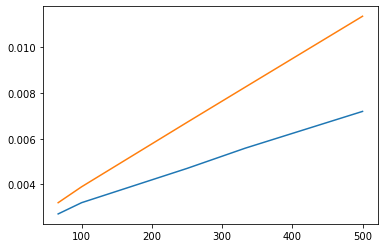

In [2]:
# Initial data
s = np.array([2.0, 3.0, 4.0, 10.0, 15.0])*1e-3  # M
r0 = np.array([139, 179, 213, 313, 370]) # rates without inhibitor
ri = np.array([88, 121, 149, 257, 313]) # rates with inhibitor
i0 = 6e-3 # inhibitor concentration, M 

# Convert both types of kinetic data to the Lineweaver-Burk form
inv_s = 1/s
inv_r0 = 1/r0
inv_ri = 1/ri

# Plot them together
plt.plot(inv_s, inv_r0)
plt.plot(inv_s, inv_ri)

# Do the fits on both of them
popt, pcov = curve_fit( linfit, inv_s, inv_r0, bounds=([-np.inf, -np.inf],[np.inf, np.inf]))
A0, B0 = popt[0], popt[1]
print(A0, B0)

popt, pcov = curve_fit( linfit, inv_s, inv_ri, bounds=([-np.inf, -np.inf],[np.inf, np.inf]))
Ai, Bi = popt[0], popt[1]
print(Ai, Bi)

In [3]:
# The intercepts are pretty close, so the inhibition is competitive,
# in this case, 
# max rate:
r_max = 2.0/(A0 + Ai)

# Michaelis and effective Michaelis (in the presence of inhibitor) constants
K_M = B0/A0
K_M_eff = Bi/Ai

# Using the following equation K_eff = K_M * (1 + [I]/K_I), solve for K_I
K_I = i0 / (K_M_eff/K_M - 1)

print(F"Michaelis constant = {K_M}, M; maximal rate = {r_max}, mkg/(L*h); inhibition constant K_I = {K_I}, M" )

Michaelis constant = 0.004873256989980063, M; maximal rate = 488.6604471677875, mkg/(L*h); inhibition constant K_I = 0.006364149478910558, M


### Answers

* $K_M = 4.9 $ mM

* $r_{max} = 489 $ mkg/(L*h)

* $K_I = 6.4 $ mM

## Problem 3

Consider the following general scheme for non-competitive inhibition:

\begin{aligned}
& E + S \overset{k_1}{\underset{k_{-1}}{\rightleftharpoons}} ES \xrightarrow{k_2} E + P,\\[4pt]
& E + I \overset{k_2'}{\underset{k_{-2}}{\rightleftharpoons}} EI,\qquad
   K_1=\dfrac{[E][I]}{[EI]},\\[4pt]
& ES + I \overset{k_3}{\underset{k_{-3}}{\rightleftharpoons}} ESI,\qquad
   K_2=\dfrac{[ES][I]}{[ESI]}.
\end{aligned}

Using the steady-state approximation for ES and quasi-equilibrium approximation for EI and ESI derive the initial reaction rate of the product formation. How are the maximal rate and the effective Michaelis constant related to the corresponding properties for the non-inhibited reaction?

### Solution

#### 1. Steady-state for \([ES]\)

Write the SSA for the intermediate \(ES\). Using quasi-equilibrium for the \(ES+I\) step means the net forward/back contribution of \($ES\leftrightarrow ESI$\) cancels, so the SSA reduces to the usual formation–loss balance:

$$
\frac{d[ES]}{dt} = k_1[E][S] - (k_{-1}+k_2)[ES] \;=\; 0.
$$

Define the Michaelis constant (for the uninhibited enzyme):

$$
K_M \equiv \frac{k_{-1}+k_2}{k_1}.
$$

Thus

$$
[ES] = \frac{[E][S]}{K_M}. \tag{1}
$$

#### 2. Total enzyme mass balance with quasi-equilibria

Total enzyme concentration:

$$
[E]_T = [E] + [ES] + [EI] + [ESI].
$$

Use the quasi-equilibrium relations:

$$
[EI] = \frac{[E][I]}{K_1},\qquad
[ESI] = \frac{[ES][I]}{K_2}.
$$

Substitute and group terms:

$$
[E]_T
= [E]\Big(1+\frac{[I]}{K_1}\Big) \;+\; [ES]\Big(1+\frac{[I]}{K_2}\Big).
$$

Use (1) to replace \($[ES]=[E][S]/K_M$\):

$$
[E]_T
= [E]\Big(1+\frac{[I]}{K_1} + \frac{[S]}{K_M}\Big(1+\frac{[I]}{K_2}\Big)\Big).
$$

Solve for \([E]\):

$$
[E] \;=\; \frac{[E]_T}{\,1+\dfrac{[I]}{K_1} \;+\; \dfrac{[S]}{K_M}\Big(1+\dfrac{[I]}{K_2}\Big)\, }.
$$

Then using (1):

$$
[ES] \;=\; \frac{[E]_T\;\dfrac{[S]}{K_M}}{\,1+\dfrac{[I]}{K_1} \;+\; \dfrac{[S]}{K_M}\Big(1+\dfrac{[I]}{K_2}\Big)\, }.
$$

#### 3. Initial rate \($v_0$\)

The initial product formation rate is

$$
v_0 \;=\; k_2[ES]
= k_2 [E]_T \,\frac{\dfrac{[S]}{K_M}}{\,1+\dfrac{[I]}{K_1} \;+\; \dfrac{[S]}{K_M}\Big(1+\dfrac{[I]}{K_2}\Big)\, }.
$$

Divide numerator and denominator by \($1+\dfrac{[I]}{K_1}$\) to put into Michaelis–Menten form:

$$
v_0 \;=\; \frac{k_2 [E]_T}{\,1+\dfrac{[I]}{K_1}\,}\;
\frac{[S]/K_M}{\,1 + \dfrac{[S]}{K_M}\dfrac{1+[I]/K_2}{1+[I]/K_1}\, }.
$$

Define the apparent (inhibited) parameters:

- Apparent maximal rate:
  $$
  V_{\max}^{\mathrm{app}} = \frac{k_2 [E]_T}{1+[I]/K_1}.
  $$

- Apparent Michaelis constant:
  $$
  K_M^{\mathrm{app}} = K_M\;\frac{1+[I]/K_2}{1+[I]/K_1}.
  $$

With these, the initial rate becomes the Michaelis–Menten form

$$
\boxed{\; v_0 \;=\; \dfrac{V_{\max}^{\mathrm{app}}\, [S]}{K_M^{\mathrm{app}} + [S]}\; }.
$$

#### 4. Note the special case

In pure non-competitive inhibition, the binding constants defined above are the same, $K_1 = K_2$ then apparent Michaelis constant simplifies:

  $$
  K_M^{\mathrm{app}} = K_M.
  $$

# 3. Problems

# 4. Solutions